# Multiple Sclerosis Lesion Segmentation: Pipeline & External Validation
**Project:** Master's Thesis (TFM)  
**Author:** Manuel Navarro Sicre  
**Framework:** [nnU-Net v2](https://github.com/MIC-DKFZ/nnUNet)

---

## 1. Overview
This notebook implements the full inference and evaluation pipeline for Multiple Sclerosis (MS) lesion segmentation. The project focuses on assessing the **generalization capability** of a deep learning model when deployed on an external, multi-center dataset.



### 1.1 The Model
* **Architecture:** nnU-Net 3d_fullres.
* **Training Data:** Multimodal MRI (FLAIR + T1-weighted).
* **Internal Performance:** DSC of 0.8149 for Class 1 (Total Lesion ) and 0.5991 for Class 2 (New Lesions).

---

## 2. The External Validation Challenge (MSLesSeg)
To evaluate the clinical translation and generalization boundaries of the trained model under a zero-shot paradigm, the **MSLesSeg** longitudinal dataset is utilized. Unlike the internal cohort, this external dataset represents raw clinical environments where images have not undergone standardized preprocessing, introducing two primary technical hurdles:

1. **Domain Shift (Raw Scanner Variations):** The imaging data originates from different scanners and centers than those used during the training phase. Crucially, these external volumes have not undergone intensity normalization or bias field correction, forcing the network to process unstandardized voxel distributions and vendor-specific noise patterns.
2. **Sparsity and Spatial Alignment Constraints:** The dataset evaluates longitudinal changes across different timepoints (t1 and t2). In raw workflows without an integrated rigid coregistration pipeline, minor sub-voxel misalignments between scans heavily penalize spatial overlap metrics (Dice Similarity Coefficient) when evaluating sparse, millimeter-scale targets such as new active lesions.

### 2.1 Modality Compatibility and Evaluation Strategy
The 3D nnU-Net v2 model requires a synchronous 4-channel input tensor per subject, structured as follows:
* **Channel 0000:** FLAIR sequence at Baseline (t1)
* **Channel 0001:** T1-weighted sequence at Baseline (t1)
* **Channel 0002:** FLAIR sequence at Follow-up (t2)
* **Channel 0003:** T1-weighted sequence at Follow-up (t2)

While other external databases like MSSEG-2 were excluded due to missing T1 sequences, the MSLesSeg dataset provides the complete 4-channel multimodal configuration required by the frozen convolutional layers. Testing the frozen weights directly on these raw files establishes a strict baseline benchmark, quantifying the exact performance limits of multi-class longitudinal models when deployed directly on raw clinical outputs.

In [ ]:
# Requirements
!pip install nnunetv2 nibabel matplotlib pandas

In [2]:
import os
import json
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import shutil
import random

In [3]:
# Environment variables
os.environ['nnUNet_raw'] = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = '/content/nnUNet_results'

In [ ]:
# Kaggle token (Username & key)
data = {"username":"xxxxx","key":"xxxxx"}  # Change "xxxxx" for your own values

with open('kaggle.json', 'w') as f:
    json.dump(data, f)

print("kaggle.json file created successfully.")

kaggle.json file created successfully.


## Upload training dataset

In [ ]:
# Move the token to the hidden settings folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download de dataset from Kaggle, faster than locally
!pip install kaggle --upgrade > /dev/null
!kaggle datasets download -d username/nnunet-ms-raw # Change "username" for yours

# Create destination folder and unzip
!mkdir -p /content/nnUNet_raw/nnunet-ms-raw
!unzip -q nnunet-ms-raw.zip -d /content/nnUNet_raw/nnunet-ms-raw

!rm nnunet-ms-raw.zip

print("Dataset ready")
!ls -l /content/nnUNet_raw/nnunet-ms-raw

Dataset URL: https://www.kaggle.com/datasets/manuelnavarrosicre/nnunet-ms-raw
License(s): unknown
100% 9.32G/9.32G [08:59<00:00, 18.5MB/s]

Dataset ready
total 4
drwxr-xr-x 4 root root 4096 May 23 23:17 Dataset001_MSLesions


In [ ]:
# Paths configuration
dataset_id = "Dataset001_MSLesions"
preprocessed_dir = f"/content/nnUNet_preprocessed/{dataset_id}/"
output_file = os.path.join(preprocessed_dir, "splits_final.json")
images_dir = f"/content/nnUNet_raw/{dataset_id}/imagesTr"

# Directory validation and file retrieval
if not os.path.exists(images_dir):
    print(f"Error: Folder not found: {images_dir}")
else:
    # Filter files belonging to channel _0000
    files = [f for f in os.listdir(images_dir) if '_0000.nii' in f]

    if len(files) == 0:
        print(f"Error: No '_0000.nii' files found in {images_dir}")
    else:
        # Extract clean nnU-Net CaseIDs (e.g., 'FIS00401_0000.nii' -> 'FIS00401')
        all_cases = sorted([f.split('_0000')[0] for f in files])

        # Group longitudinal studies by stripping the last 2 digits
        patient_to_cases = {}
        for case in all_cases:
            # Strip last two digits to isolate the unique patient ID (e.g., 'FIS01901' -> 'FIS019')
            patient_id = case[:-2]

            if patient_id not in patient_to_cases:
                patient_to_cases[patient_id] = []
            patient_to_cases[patient_id].append(case)

        unique_patients = list(patient_to_cases.keys())

        # Reproducible random shuffle
        random.seed(42)
        random.shuffle(unique_patients)

        # Distribute unique patients into 5 cyclic folds
        num_splits = 5
        fold_patients = [[] for _ in range(num_splits)]

        for idx, patient in enumerate(unique_patients):
            fold_patients[idx % num_splits].append(patient)

        custom_splits = []
        for i in range(num_splits):
            val_patients = fold_patients[i]
            train_patients = [p for p in unique_patients if p not in val_patients]

            # Recombine all timepoints for the assigned train/val patients
            train_cases = []
            for p in train_patients:
                train_cases.extend(patient_to_cases[p])

            val_cases = []
            for p in val_patients:
                val_cases.extend(patient_to_cases[p])

            custom_splits.append({
                "train": train_cases,
                "val": val_cases
            })

        # Save splits_final.json file
        os.makedirs(preprocessed_dir, exist_ok=True)
        with open(output_file, 'w') as f:
            json.dump(custom_splits, f, indent=4)

        print(f"Total longitudinal studies processed: {len(all_cases)}")
        print(f"Total unique patients grouped: {len(unique_patients)}")
        print(f"Fold 0 validation set configured with: {len(custom_splits[0]['val'])} studies.")

        # Quality control sample display
        print("\nGrouping Sample (Quality Control):")
        examples = [p for p in unique_patients if len(patient_to_cases[p]) > 1][:3]
        for p in examples:
            print(f" Patient {p} -> Grouped studies: {patient_to_cases[p]}")

### Generate dataset.json

In [ ]:
target_folder = '/content/nnUNet_raw/Dataset001_MSLesions'

dataset_json = {
    "channel_names": {
        "0": "FLAIR_baseline",
        "1": "T1_baseline",
        "2": "FLAIR_followup",
        "3": "T1_followup"
    },
    "labels": {
        "background": 0,
        "stable_lesions": 1,
        "new_lesions": 2,
        "growing_lesions": 3
    },
    "numTraining": 349,
    "file_ending": ".nii"
}

with open(os.path.join(target_folder, 'dataset.json'), 'w') as f:
    json.dump(dataset_json, f, indent=4)

print("dataset.json file create successfully.")

### Run planning and preprocessing

In [ ]:
# -d: Dataset ID (1)
# -c: Configuration (3d_fullres)
# --verify_dataset_integrity: Checks for format errors before starting
!nnUNetv2_plan_and_preprocess -d 1 -c 3d_fullres --verify_dataset_integrity

Fingerprint extraction...
Dataset001_MSLesions
Using <class 'nnunetv2.imageio.nibabel_reader_writer.NibabelIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.nibabel_reader_writer.NibabelIO'> as reader/writer
Extracting dataset fingerprint: 100% 349/349 [02:43<00:00,  2.13it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [156. 154. 200.], 3d_lowres: [156, 154, 200]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size':

### Run training

In [ ]:
# 1: Dataset ID
# 3d_fullres: Configuration
# 0: Fold number (0-4)
# To train a full model, you would normally run 5 folds.
#!nnUNetv2_train Dataset001_MSLesions 3d_fullres 0
print("Training command: nnUNetv2_train 1 3d_fullres 0")
print("Note: This step was previously completed. Pre-trained weights are located in the nnUNet_results folder.")

Se han truncado las últimas 5000 líneas del flujo de salida.
2026-05-22 22:52:41.851345: Pseudo dice [np.float32(0.8464), np.float32(0.6596), np.float32(nan)]
2026-05-22 22:52:41.851620: Epoch time: 67.88 s
2026-05-22 22:52:43.318753: 
2026-05-22 22:52:43.319174: Epoch 272
2026-05-22 22:52:43.319394: Current learning rate: 0.00751
2026-05-22 22:53:52.516659: train_loss -0.6224
2026-05-22 22:53:52.517029: val_loss -0.5883
2026-05-22 22:53:52.517215: Pseudo dice [np.float32(0.8425), np.float32(0.6057), np.float32(nan)]
2026-05-22 22:53:52.517383: Epoch time: 69.2 s
2026-05-22 22:53:53.964353: 
2026-05-22 22:53:53.964754: Epoch 273
2026-05-22 22:53:53.964973: Current learning rate: 0.00751
2026-05-22 22:55:01.734082: train_loss -0.6234
2026-05-22 22:55:01.734650: val_loss -0.5829
2026-05-22 22:55:01.734930: Pseudo dice [np.float32(0.8546), np.float32(0.6554), np.float32(nan)]
2026-05-22 22:55:01.735170: Epoch time: 67.77 s
2026-05-22 22:55:03.334534: 
2026-05-22 22:55:03.335014: Epoch 274

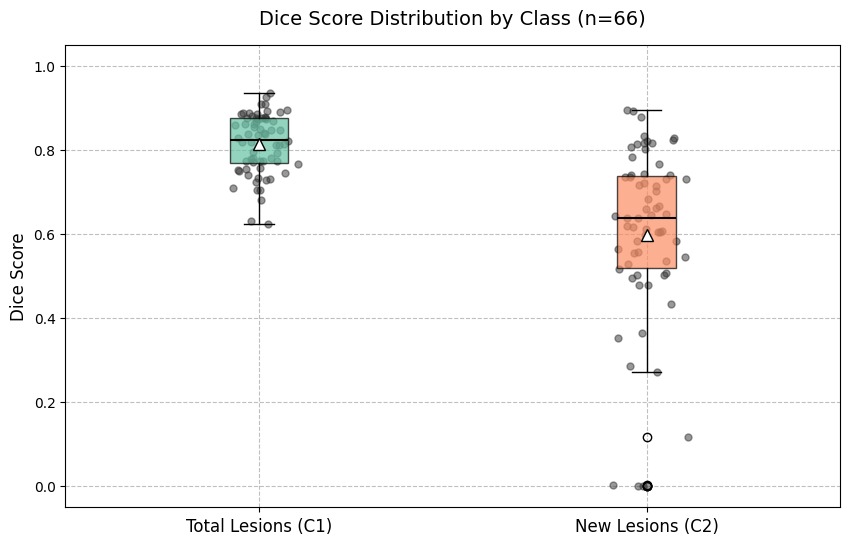

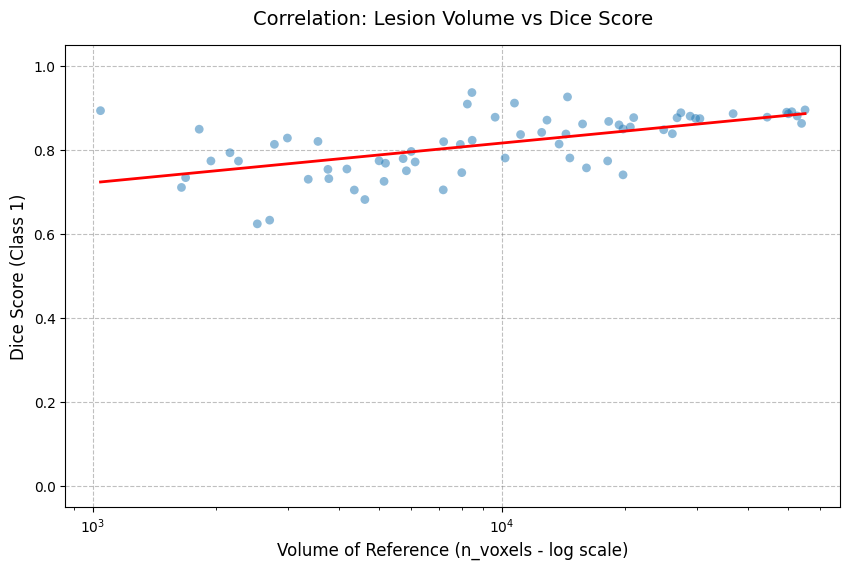

In [ ]:
json_path = '/content/nnUNet_results/Dataset001_MSLesions/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/summary.json'

with open(json_path) as f:
    data = json.load(f)

cases = []
for case in data['metric_per_case']:
    case_id = case['prediction_file'].split('/')[-1].replace('.nii.gz', '')
    cases.append({
        'Case': case_id,
        'Dice_Total': case['metrics']['1']['Dice'],
        'Dice_New': case['metrics']['2']['Dice'],
        'Volume_Total': case['metrics']['1']['n_ref']
    })

df = pd.DataFrame(cases)

# Handle missing values to prevent plotting errors
dice_total_clean = df['Dice_Total'].dropna()
dice_new_clean = df['Dice_New'].dropna()

# PLOT 1: Performance Comparison Across Classes (Boxplot with Jitter)
plt.figure(figsize=(10, 6))

# Enable background grid matrix
plt.gca().set_axisbelow(True)
plt.grid(True, linestyle='--', alpha=0.5, color='gray')

# Generate base boxplots at discrete X-positions (1 and 2)
colors = ['#66c2a5', '#fc8d62']
bp = plt.boxplot([dice_total_clean, dice_new_clean], patch_artist=True, showmeans=True,
                 meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": 8},
                 medianprops={"color": "black", "linewidth": 1.5})

# Apply colors and transparency to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add manual horizontal jitter to scatter points (sns.stripplot alternative)
# Class 1 distribution (centered around X = 1)
x_jitter_1 = np.random.normal(1, 0.04, size=len(dice_total_clean))
plt.scatter(x_jitter_1, dice_total_clean, color='#333333', alpha=0.5, s=25, label='Individual cases')

# Class 2 distribution (centered around X = 2)
x_jitter_2 = np.random.normal(2, 0.04, size=len(dice_new_clean))
plt.scatter(x_jitter_2, dice_new_clean, color='#333333', alpha=0.5, s=25)

# Plot 1 formatting properties
plt.title(f'Dice Score Distribution by Class (n={len(df)})', fontsize=14, pad=15)
plt.ylabel('Dice Score', fontsize=12)
plt.xticks([1, 2], ['Total Lesions (C1)', 'New Lesions (C2)'], fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend(loc='upper right')

plt.savefig('boxplot_dice_classes.png', dpi=300, bbox_inches='tight')
plt.show()


# PLOT 2: Small Object Assessment (Volume vs. Dice Score)
plt.figure(figsize=(10, 6))

# Filter out non-positive volumes to prevent log-scale runtime errors
df_reg = df.dropna(subset=['Volume_Total', 'Dice_Total'])
df_reg = df_reg[df_reg['Volume_Total'] > 0]

x_vol = df_reg['Volume_Total'].values
y_dice = df_reg['Dice_Total'].values

# Enable background grid matrix
plt.gca().set_axisbelow(True)
plt.grid(True, linestyle='--', alpha=0.5, color='gray')

# Render scatter plot coordinates
plt.scatter(x_vol, y_dice, color='#1f77b4', alpha=0.5, s=40, edgecolors='none')

# Fit trendline over log10(X) to ensure a linear fit across the log scale
idx_valid = np.isfinite(x_vol) & np.isfinite(y_dice)
coefficients = np.polyfit(np.log10(x_vol[idx_valid]), y_dice[idx_valid], 1)
poly_function = np.poly1d(coefficients)

# Generate bounding coordinates for the trendline limits
x_line = np.logspace(np.log10(x_vol.min()), np.log10(x_vol.max()), 100)
y_line = poly_function(np.log10(x_line))

# Plot calculated regression trendline
plt.plot(x_line, y_line, color='red', linewidth=2, label='Trend')

# Set X-axis to logarithmic scale
plt.xscale('log')

# Plot 2 formatting properties
plt.title('Correlation: Lesion Volume vs. Dice Score', fontsize=14, pad=15)
plt.xlabel('Volume of Reference (n_voxels - log scale)', fontsize=12)
plt.ylabel('Dice Score (Class 1)', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend(loc='lower right')

plt.savefig('correlation_vol_dice.png', dpi=300, bbox_inches='tight')
plt.show()

### MRI Comparison Generation

Automatically selected slice with highest predicted lesion load: 160


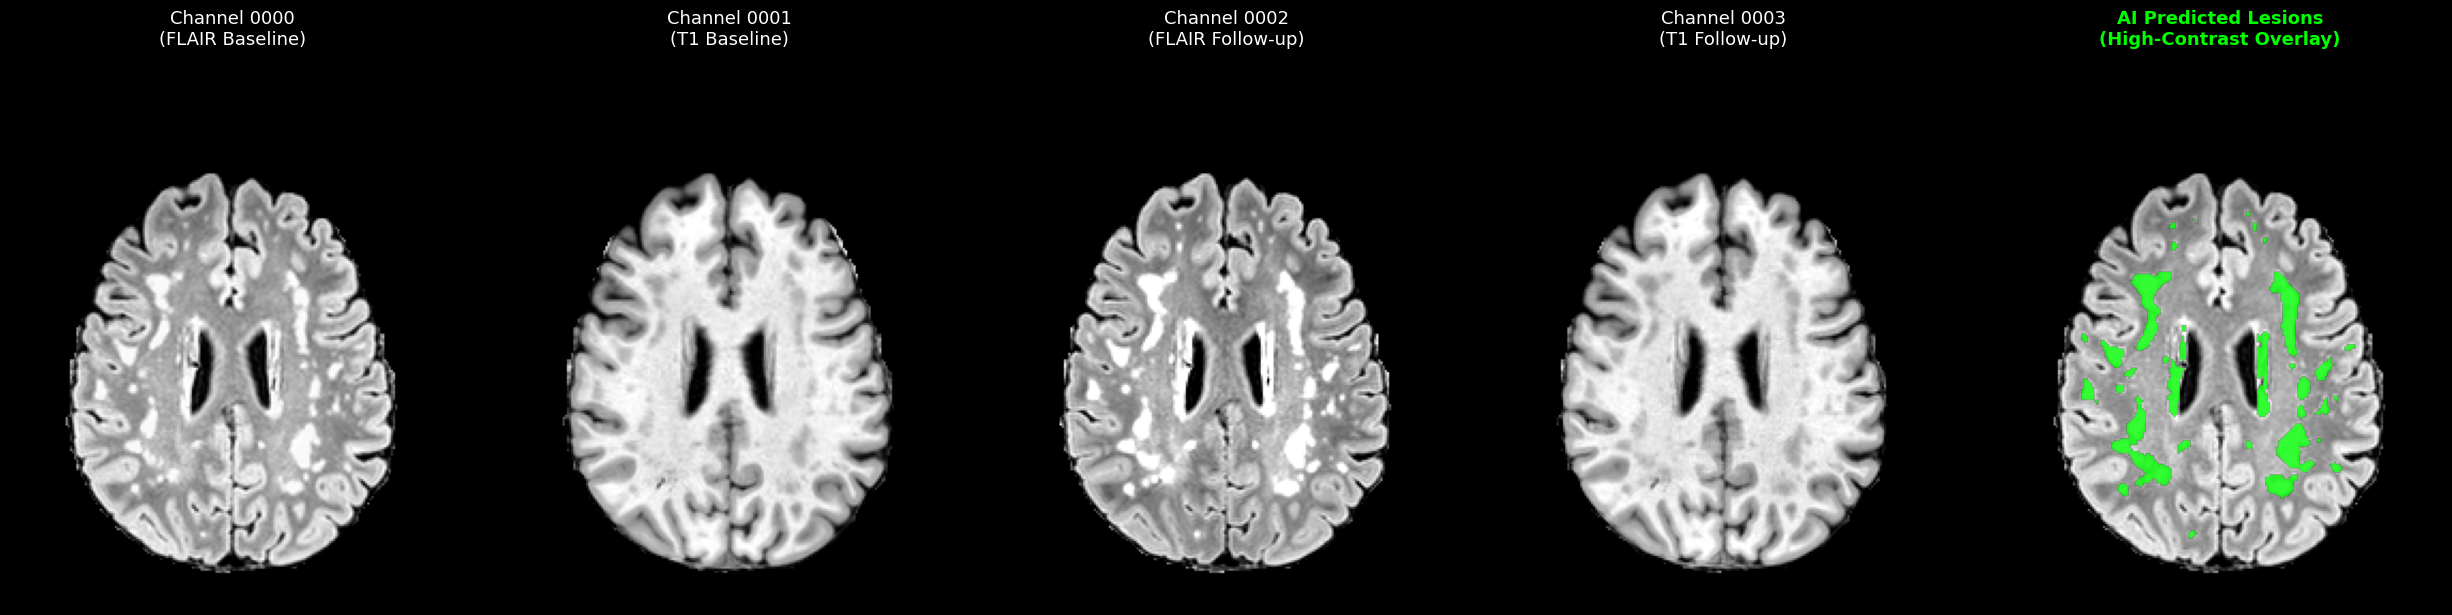

In [ ]:

DATA_DIR = '/content/'
CASE_ID = 'MSVIS00305'  # To be changed for any other file or path

ch0_path = os.path.join(DATA_DIR, f'{CASE_ID}_0000.nii')
ch1_path = os.path.join(DATA_DIR, f'{CASE_ID}_0001.nii')
ch2_path = os.path.join(DATA_DIR, f'{CASE_ID}_0002.nii')
ch3_path = os.path.join(DATA_DIR, f'{CASE_ID}_0003.nii')
pred_path = os.path.join(DATA_DIR, f'{CASE_ID}.nii')

# Load data
img_0 = nib.load(ch0_path).get_fdata()
img_1 = nib.load(ch1_path).get_fdata()
img_2 = nib.load(ch2_path).get_fdata()
img_3 = nib.load(ch3_path).get_fdata()
img_pred = nib.load(pred_path).get_fdata()

# Best section of the lesion
best_slice = np.argmax(np.sum(img_pred > 0, axis=(0, 1)))
print(f"Automatically selected slice with highest predicted lesion load: {best_slice}")

# Function to apply contrast
def get_contrast_limits(slice_data, p_min=1.0, p_max=99.5):
    brain_voxels = slice_data[slice_data > 0]
    if len(brain_voxels) == 0:
        return None, None
    return np.percentile(brain_voxels, p_min), np.percentile(brain_voxels, p_max)

ai_color = 'lime'
cmap_ai = LinearSegmentedColormap.from_list('solid_ai', [ai_color, ai_color], N=2)

# Plot the high-contrast 5-column panel
fig, axes = plt.subplots(1, 5, figsize=(25, 6), facecolor='black') # Black background for maximum pop

images = [img_0, img_1, img_2, img_3]
titles = [
    'Channel 0000\n(FLAIR Baseline)',
    'Channel 0001\n(T1 Baseline)',
    'Channel 0002\n(FLAIR Follow-up)',
    'Channel 0003\n(T1 Follow-up)'
]

# Plot standard input channels with local contrast adaptation
for i in range(4):
    slice_to_show = np.rot90(images[i][:, :, best_slice])
    vmin, vmax = get_contrast_limits(slice_to_show)

    axes[i].imshow(slice_to_show, cmap='gray', vmin=vmin, vmax=vmax)
    axes[i].set_title(titles[i], fontsize=13, color='white', pad=10)

# Column 5: High-Contrast Overlay (AI Prediction on FLAIR Baseline)
flair_bg = np.rot90(img_0[:, :, best_slice])
vmin_f, vmax_f = get_contrast_limits(flair_bg)

# Base structural image
axes[4].imshow(flair_bg, cmap='gray', vmin=vmin_f, vmax=vmax_f)

# Processed mask overlay
pred_mask = np.rot90(img_pred[:, :, best_slice])
masked_pred = np.ma.masked_where(pred_mask == 0, pred_mask)

# Overlaying with solid color and perfect transparency alpha
axes[4].imshow(masked_pred, cmap=cmap_ai, alpha=0.8)
axes[4].set_title('AI Predicted Lesions\n(High-Contrast Overlay)', fontsize=13, color='lime', pad=10, weight='bold')

# Clean up layout axes
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'high_contrast_prediction_{CASE_ID}.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## Upload validation dataset

In [5]:
# Move the token to the hidden settings folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download de dataset from Kaggle, faster than locally
!pip install kaggle --upgrade > /dev/null
!kaggle datasets download -d username/MSLegSeg # Change "username" for yours

# Create destination folder and unzip
!mkdir -p /content/nnUNet_raw/MSLegSeg
!unzip -q MSLegSeg.zip -d /content/nnUNet_raw/MSLegSeg

!rm MSLegSeg.zip

print("Dataset ready")
!ls -l /content/nnUNet_raw/MSLegSeg

Dataset URL: https://www.kaggle.com/datasets/manuelnavarrosicre/MSLegSeg
License(s): CC0-1.0
100% 1.43G/1.43G [01:21<00:00, 18.8MB/s]

Dataset ready
total 4
drwxr-xr-x 5 root root 4096 May 24 17:34 'MSLesSeg Dataset'


In [ ]:
SOURCE_TRAIN_DIR = "/content/nnUNet_raw/MSLegSeg/MSLesSeg Dataset/train"
INPUT_NNUNET_DIR = '/content/external_longitudinal_input/'

# Clear previous runs to avoid file extension conflicts
if os.path.exists(INPUT_NNUNET_DIR):
    shutil.rmtree(INPUT_NNUNET_DIR)
os.makedirs(INPUT_NNUNET_DIR, exist_ok=True)

patients = sorted([f for f in os.listdir(SOURCE_TRAIN_DIR) if os.path.isdir(os.path.join(SOURCE_TRAIN_DIR, f))])
longitudinal_patients = []

print(f"Starting direct file transfer in rigid .nii format at: {SOURCE_TRAIN_DIR}\n")

for patient in patients:
    patient_path = os.path.join(SOURCE_TRAIN_DIR, patient)
    valid_subfolders = []

    for subfolder in sorted(os.listdir(patient_path)):
        subfolder_path = os.path.join(patient_path, subfolder)
        if os.path.isdir(subfolder_path):
            files = os.listdir(subfolder_path)

            flair_found = None
            t1_found = None

            for file_name in files:
                file_name_lower = file_name.lower()
                if file_name_lower.endswith('.nii'):
                    if 'flair' in file_name_lower:
                        flair_found = file_name
                    elif 't1' in file_name_lower and 'flair' not in file_name_lower:
                        t1_found = file_name

            if flair_found and t1_found:
                valid_subfolders.append((subfolder, flair_found, t1_found))

    valid_subfolders = sorted(valid_subfolders)

    # Ensure patient has at least a baseline and a follow-up study
    if len(valid_subfolders) >= 2:
        baseline_info = valid_subfolders[0]  # Timepoint 1
        followup_info = valid_subfolders[1]  # Timepoint 2

        flair_baseline = os.path.join(patient_path, baseline_info[0], baseline_info[1])
        t1_baseline    = os.path.join(patient_path, baseline_info[0], baseline_info[2])
        flair_followup = os.path.join(patient_path, followup_info[0], followup_info[1])
        t1_followup    = os.path.join(patient_path, followup_info[0], followup_info[2])

        case_id = f"LONG_{patient}"

        # Direct copy and sequential indexing matching nnU-Net channel formats
        shutil.copy(flair_baseline, os.path.join(INPUT_NNUNET_DIR, f"{case_id}_0000.nii"))
        shutil.copy(t1_baseline,    os.path.join(INPUT_NNUNET_DIR, f"{case_id}_0001.nii"))
        shutil.copy(flair_followup, os.path.join(INPUT_NNUNET_DIR, f"{case_id}_0002.nii"))
        shutil.copy(t1_followup,    os.path.join(INPUT_NNUNET_DIR, f"{case_id}_0003.nii"))

        longitudinal_patients.append({
            'id': patient,
            'case_id': case_id,
            'tp_base_dir': baseline_info[0],
            'tp_evol_dir': followup_info[0]
        })
        print(f"  {patient}: Successfully mapped to .nii [{baseline_info[0]} ➔ {followup_info[0]}]")

print(f"File transfer completed.")
print(f"Total longitudinal pairs ready in .nii: {len(longitudinal_patients)}")

### Run inference (external validation)


In [15]:
# -i: Input folder containing the prepared 4-channel images
# -o: Output folder where the predicted lesion masks will be saved
# -d: Dataset ID (1) corresponding to the training configuration
# -c: Model configuration (3d_fullres) for maximum spatial precision
# -f: Fold index (0) to load weights from the first cross-validation fold
# -chk: Specific checkpoint filename to load the best historical weights (by default: checkpoint_final.pth)
!nnUNetv2_predict -i /content/external_longitudinal_input -o /content/external_longitudinal_predictions -d 1 -c 3d_fullres -f 0 -chk checkpoint_best.pth


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 25 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 25 cases that I would like to predict

Predicting LONG_P1:
perform_everything_on_device: True
100% 12/12 [00:03<00:00,  3.34it/s]
sending off prediction to background worker for resampling and export
done with LONG_P1

Predicting LONG_P10:
perform_everything_on_device: True
100% 12/12 [00:02<00:00,  5.23it/s]
sending off prediction to background worker for resampling and export
done with LONG_P10

Predicting LONG_P11:
perform_everything_on_device: True
100% 12/12 [00

In [ ]:
def dice_coefficient(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    denominator = np.sum(y_true) + np.sum(y_pred)
    if denominator == 0: 
        return 1.0  # Avoids penalizing if the patient has no true active disease burden
    return (2. * intersection) / (denominator + 1e-8)

# Path configuration
SOURCE_TRAIN_DIR = "/content/nnUNet_raw/MSLegSeg/MSLesSeg Dataset/train"
PATH_PRED_DIR = '/content/external_longitudinal_predictions/'
OUTPUT_CSV_PATH = 'external_validation_results.csv'
final_results = []

if not os.path.exists(PATH_PRED_DIR):
    print("Error: Prediction folder not found. Ensure STEP 2 has completed successfully.")
else:
    # Locate AI-generated files in native .nii format
    predicted_files = sorted([f for f in os.listdir(PATH_PRED_DIR) if f.startswith('LONG_') and f.endswith('.nii')])
    print(f"Analyzing {len(predicted_files)} segmented external longitudinal cases...\n")

    for f in predicted_files:
        case_id = f.replace('.nii', '')
        patient = case_id.replace('LONG_', '')
        patient_path = os.path.join(SOURCE_TRAIN_DIR, patient)
        
        # Adaptive scanning of timepoint folders for this specific patient
        valid_subfolders = []
        for subfolder in sorted(os.listdir(patient_path)):
            subfolder_path = os.path.join(patient_path, subfolder)
            if os.path.isdir(subfolder_path):
                folder_files = os.listdir(subfolder_path)
                has_flair = any('flair' in a.lower() and a.lower().endswith('.nii') for a in folder_files)
                has_t1 = any('t1' in a.lower() and 'flair' not in a.lower() and a.lower().endswith('.nii') for a in folder_files)
                if has_flair and has_t1:
                    valid_subfolders.append(subfolder)
                    
        valid_subfolders = sorted(valid_subfolders)
        
        if len(valid_subfolders) >= 2:
            tp_base_dir = valid_subfolders[0]  # Baseline timepoint (t1)
            tp_evol_dir = valid_subfolders[1]  # Follow-up timepoint (t2)
            
            path_base_dir = os.path.join(patient_path, tp_base_dir)
            path_evol_dir = os.path.join(patient_path, tp_evol_dir)
            
            # Auto-detect native ground truth mask file names
            mask_base_file = next((m for m in os.listdir(path_base_dir) if m.lower().endswith('.nii') and any(k in m.lower() for k in ['mask', 'mascara', 'gt'])), None)
            mask_evol_file = next((m for m in os.listdir(path_evol_dir) if m.lower().endswith('.nii') and any(k in m.lower() for k in ['mask', 'mascara', 'gt'])), None)
            
            if mask_base_file and mask_evol_file:
                # Load 3D prediction volume generated by nnU-Net
                pred_img = nib.load(os.path.join(PATH_PRED_DIR, f)).get_fdata()
                
                # Load expert binary ground truth maps
                gt_base = (nib.load(os.path.join(path_base_dir, mask_base_file)).get_fdata() > 0).astype(float)
                gt_evol = (nib.load(os.path.join(path_evol_dir, mask_evol_file)).get_fdata() > 0).astype(float)
                
                # Logical subtraction: Lesions present at follow-up (t2) that did not exist at baseline (t1)
                gt_new_lesions = ((gt_evol == 1) & (gt_base == 0)).astype(float)
                
                # Isolate categorical target maps estimated by the multi-class framework
                pred_class_1 = (pred_img == 1).astype(float)  # Total/stable lesion burden
                pred_class_2 = (pred_img == 2).astype(float)  # New active lesions
               
                # Compute regional evaluation metrics
                dice_c1 = dice_coefficient(gt_evol, pred_class_1)
                dice_c2 = dice_coefficient(gt_new_lesions, pred_class_2)
                
                final_results.append({
                    'Patient': patient,
                    'Dice_C1_Total': round(dice_c1, 4),
                    'Dice_C2_New': round(dice_c2, 4)
                })

    # Render formal report using a Pandas DataFrame structure
    df_validation = pd.DataFrame(final_results)
    df_validation.to_csv(OUTPUT_CSV_PATH, index=False)
    print("COMPLETE EXTERNAL LONGITUDINAL VALIDATION (FINAL DATA)\n")
    print(df_validation.to_string(index=False))
    print(f"\nMEAN DICE CLASS 1 (TOTAL LESIONS): {round(df_validation['Dice_C1_Total'].mean(), 4)}")
    print(f"MEAN DICE CLASS 2 (NEW LESIONS):   {round(df_validation['Dice_C2_New'].mean(), 4)}")

### MRI Comparison Generation

In [ ]:
PATIENT = "P8"  # Change to "P14", "P1", or "P8" for specific case studies
SOURCE_TRAIN_DIR = "/content/nnUNet_raw/MSLegSeg/MSLesSeg Dataset/train"
PRED_DIR = '/content/external_longitudinal_predictions'

print(f"Searching 3D volume structures for Patient {PATIENT}...")

# Flexibly locate patient directories
patient_path = os.path.join(SOURCE_TRAIN_DIR, PATIENT)
subfolders = sorted([f for f in os.listdir(patient_path) if os.path.isdir(os.path.join(patient_path, f))])

# Select the latest timepoint (follow-up/evolutionary) to evaluate lesions
followup_dir = os.path.join(patient_path, subfolders[-1])

flair_file = next((f for f in os.listdir(followup_dir) if 'flair' in f.lower() and f.endswith('.nii')), None)
mask_file = next((f for f in os.listdir(followup_dir) if f.lower().endswith('.nii') and any(k in f.lower() for k in ['mask', 'mascara', 'gt'])), None)
pred_file = f"LONG_{PATIENT}.nii"

# Verify that AI predictions exist
if not os.path.exists(os.path.join(PRED_DIR, pred_file)):
    print(f"Error: AI prediction file ({pred_file}) not found in {PRED_DIR}. Ensure STEP 2 completed successfully.")
else:
    # Load medical imaging data arrays
    flair_img = nib.load(os.path.join(followup_dir, flair_file)).get_fdata()
    gt_img = nib.load(os.path.join(followup_dir, mask_file)).get_fdata()
    pred_img = nib.load(os.path.join(PRED_DIR, pred_file)).get_fdata()

    # Automated lesion detection: search for the slice with maximum pathology load
    lesion_pixels_per_slice = np.sum(gt_img > 0, axis=(0, 1))
    best_slice = np.argmax(lesion_pixels_per_slice)

    print(f"Optimal slice automatically detected: Slice No. {best_slice}")

    # Extract 2D planes from the selected slice
    slice_flair = flair_img[:, :, best_slice]
    slice_gt = gt_img[:, :, best_slice]
    slice_pred = pred_img[:, :, best_slice]

    # Rotate 90 degrees for correct anatomical orientation (eyes facing upwards)
    slice_flair = np.rot90(slice_flair)
    slice_gt = np.rot90(slice_gt)
    slice_pred = np.rot90(slice_pred)

    # Construct a 3-panel scientific journal style figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='black')

    # Panel A: Raw Source FLAIR Sequence
    axes[0].imshow(slice_flair, cmap='gray')
    axes[0].set_title(f"A) Raw FLAIR Input ({PATIENT})", color='white', fontsize=14, pad=10)
    axes[0].axis('off')

    # Panel B: Expert Clinical Annotation (Ground Truth) using a warm colormap
    axes[1].imshow(slice_flair, cmap='gray')
    # 'masked_where' keeps the background transparent, overlaying only the lesions
    mask_overlay = np.ma.masked_where(slice_gt == 0, slice_gt)
    axes[1].imshow(mask_overlay, cmap='autumn', alpha=0.65)
    axes[1].set_title("B) Expert Ground Truth", color='white', fontsize=14, pad=10)
    axes[1].axis('off')

    # Panel C: Mathematical multi-class prediction generated by nnU-Net
    axes[2].imshow(slice_flair, cmap='gray')
    pred_overlay = np.ma.masked_where(slice_pred == 0, slice_pred)
    axes[2].imshow(pred_overlay, cmap='winter', alpha=0.65)
    axes[2].set_title("C) nnU-Net 3D Prediction", color='white', fontsize=14, pad=10)
    axes[2].axis('off')

    plt.tight_layout()

    output_name = f"validation_comparison_{PATIENT}.png"
    plt.savefig(output_name, facecolor=fig.get_facecolor(), edgecolor='none', dpi=300)
    plt.show()

    print(f"\nFigure generated")
    print(f"Filename: '{output_name}'")